In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score, recall_score,
     f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, RocCurveDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [2]:
applicants_df=pd.read_csv("credit_applicants.csv")
print("Default rate: {:.1%}".format(applicants_df["default"].mean()))

missing_credit_score=applicants_df[applicants_df["credit_bureau_score"].isna()]
print("Thin file applicants proportion: {:.1%}".format(len(missing_credit_score)/len(applicants_df)))

applicants_df["is_thin_file"]=applicants_df["credit_bureau_score"].isna().astype(int)
display(applicants_df[['applicant_id', 'credit_bureau_score', 'is_thin_file']].head())

##is_thin_file flag tells if the particular applicant has no credit bureau score (1), or if they do (0) 

Default rate: 20.2%
Thin file applicants proportion: 20.0%


,applicant_id,credit_bureau_score,is_thin_file
0,APP1000,NaN,1
1,APP1001,380.0,0
2,APP1002,788.0,0
3,APP1003,387.0,0
4,APP1004,493.0,0


 Stratifying default as the default rate is 20%, meaning a split done randomly can remove any defaults.

In [3]:
features = [
    "age", "monthly_income_inr", "existing_loans_count", "credit_utilization_ratio",
    "upi_monthly_inflow_inr", "bounced_payments_count", "credit_bureau_score", "employment_type", "is_thin_file"
]

X = applicants_df[features].copy()
y = applicants_df["default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print("Training applicants:", len(X_train), " | Test applicants:", len(X_test))

Training applicants: 300  | Test applicants: 100


For the purpose of populating the NaN values (credit_bureau_score) in the dataset, median will be used. But in order to not let the Training data leak into the Test data, the sratified split is performed before the median calculation. Also the median is calculated using only the train data, and then used to populate the NaN values in both Test and Train data. This is done as per the StandardScaler fit-on-train-only rule.

For the purpose of encoding, one-hot encoder is used. Unlike label encoding, one-hot does not change individual categories into numbers, rather creates dummy columns for each of the categories with binary entries (0 or 1).

In [4]:
##Median Calculation
train_median_score = X_train["credit_bureau_score"].median()
X_train["credit_bureau_score"] = X_train["credit_bureau_score"].fillna(train_median_score)
X_test["credit_bureau_score"] = X_test["credit_bureau_score"].fillna(train_median_score)

##employment_type encoded using one-hot encoder
X_train_encoded = pd.get_dummies(X_train, columns=["employment_type"], drop_first=True, dtype=int)
X_test_encoded = pd.get_dummies(X_test, columns=["employment_type"], drop_first=True, dtype=int)

numeric_cols = [
    "age", "monthly_income_inr", "existing_loans_count", 
    "credit_utilization_ratio", "upi_monthly_inflow_inr", 
    "bounced_payments_count", "credit_bureau_score"
]

scaler = StandardScaler()

scaler.fit(X_train_encoded[numeric_cols])

X_train_encoded[numeric_cols] = scaler.transform(X_train_encoded[numeric_cols])
X_test_encoded[numeric_cols] = scaler.transform(X_test_encoded[numeric_cols])

print("Imputed missing bureau scores with training median:", train_median_score)
print("Processed Training Shape:", X_train_encoded.shape)
display(X_train_encoded.head())

Imputed missing bureau scores with training median: 612.0
Processed Training Shape: (300, 10)


,age,monthly_income_inr,existing_loans_count,credit_utilization_ratio,upi_monthly_inflow_inr,bounced_payments_count,credit_bureau_score,is_thin_file,employment_type_salaried,employment_type_self_employed
84,-1.145762,0.952812,0.053277,0.149735,0.995851,-0.227884,-0.148387,0,0,1
10,0.270945,-1.385434,-0.641639,-0.587877,-1.151228,-0.227884,0.048994,1,1,0
384,0.713666,-1.586508,-0.641639,-1.436132,0.076032,-1.127427,0.127947,0,0,1
359,-0.171776,0.287041,0.053277,1.588080,-0.656830,-0.227884,1.338550,0,0,0
11,1.333476,-0.576811,1.443108,0.186616,1.211575,-0.227884,0.476653,0,1,0


--- SIDE-BY-SIDE MODEL COMPARISON ---


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Model,,,,,
Logistic Regression,0.76,0.3889,0.35,0.3684,0.7188
Decision Tree,0.65,0.2222,0.30,0.2553,0.5188


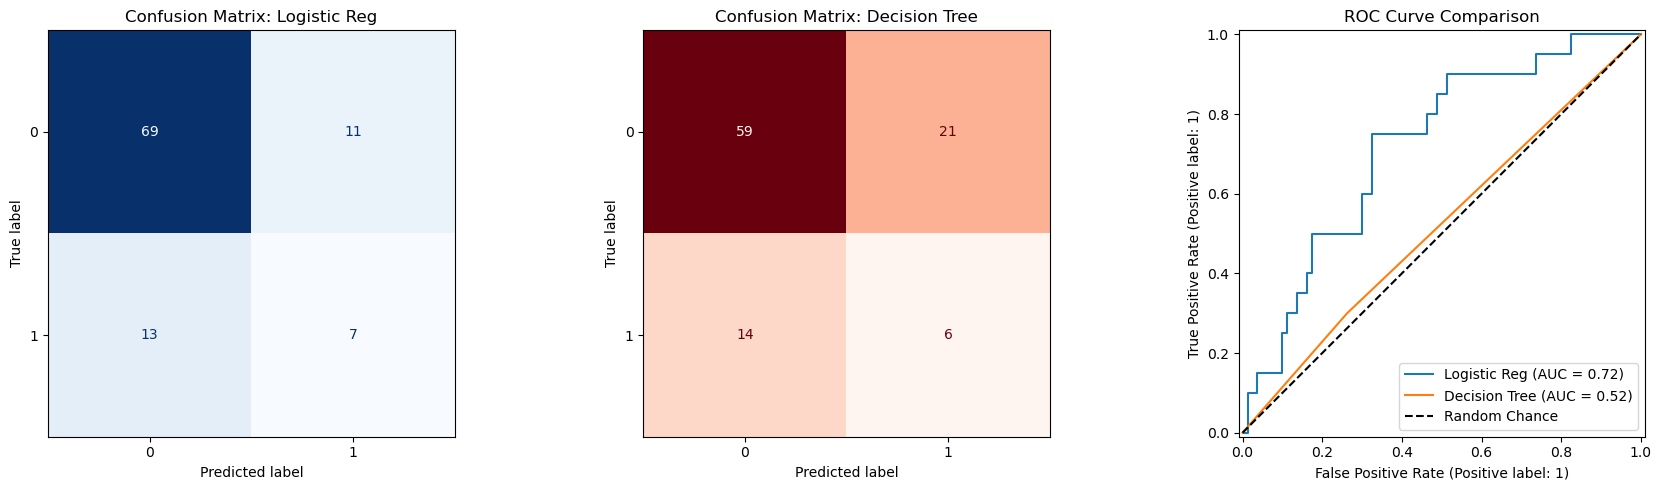

In [17]:
##Logistic Regression & Decision Tree classifier
##Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_encoded, y_train)

##Decision Tree Classifier
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train_encoded, y_train)

##Metrics
models = {'Logistic Regression': log_reg, 'Decision Tree': dt_clf}
comparison_data = []

for name, model in models.items():
    y_pred = model.predict(X_test_encoded)
    y_proba = model.predict_proba(X_test_encoded)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    
    comparison_data.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'ROC AUC': auc
    })

#Comparision table for Regression & Decision Tree
metrics_df = pd.DataFrame(comparison_data).set_index('Model')
print("--- SIDE-BY-SIDE MODEL COMPARISON ---")
display(metrics_df.round(4))

##Confusion Matrix and ROC curve
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_estimator(log_reg, X_test_encoded, y_test, 
                                      cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix: Logistic Reg')

ConfusionMatrixDisplay.from_estimator(dt_clf, X_test_encoded, y_test, 
                                      cmap='Reds', ax=axes[1], colorbar=False)
axes[1].set_title('Confusion Matrix: Decision Tree')

RocCurveDisplay.from_estimator(log_reg, X_test_encoded, y_test, ax=axes[2], name='Logistic Reg')
RocCurveDisplay.from_estimator(dt_clf, X_test_encoded, y_test, ax=axes[2], name='Decision Tree')
axes[2].set_title('ROC Curve Comparison')
axes[2].plot([0, 1], [0, 1], 'k--', label='Random Chance')
axes[2].legend()

plt.tight_layout()
plt.savefig('confusion_matrix_charts.png', dpi=300, bbox_inches='tight')
plt.show()

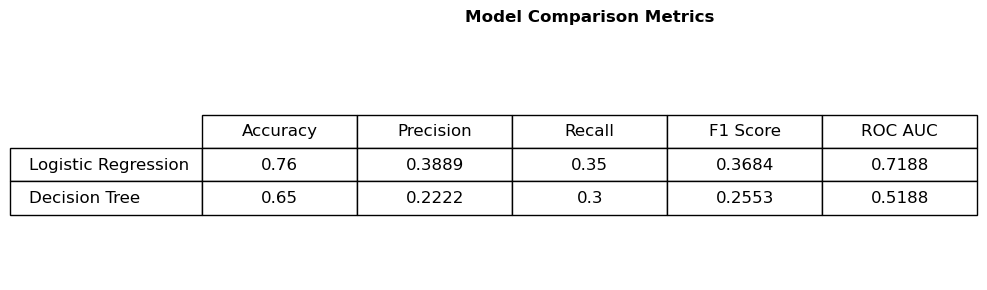

In [22]:
##Side-by-Side model comparision table as an image
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off') # Hide the standard chart axes
table = ax.table(cellText=metrics_df.round(4).values, 
                 colLabels=metrics_df.columns, 
                 rowLabels=metrics_df.index, 
                 loc='center', 
                 cellLoc='center')

table.scale(1, 2)
table.auto_set_font_size(False)
table.set_fontsize(12)
plt.title("Model Comparison Metrics", fontweight='bold', pad=20)

plt.savefig('model_side-by-side_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [23]:
##Risk based pricing- assigning interest rates
pricing_df = pd.DataFrame({
    'Actual_Default': y_test,
    'Predicted_Prob': log_reg.predict_proba(X_test_encoded)[:, 1]
})

pricing_df['Risk_Tier'] = pd.qcut(
    pricing_df['Predicted_Prob'], 
    q=4, 
    labels=['Tier 1 (Low Risk)', 'Tier 2 (Medium Risk)', 'Tier 3 (High Risk)', 'Tier 4 (Very High Risk)']
)

##Assumed interest rate valuess for each bucket
interest_rate_map = {
    'Tier 1 (Low Risk)': '8.0%',
    'Tier 2 (Medium Risk)': '12.5%',
    'Tier 3 (High Risk)': '18.0%',
    'Tier 4 (Very High Risk)': '22.5%'
}
pricing_df['Assigned_Interest_Rate'] = pricing_df['Risk_Tier'].map(interest_rate_map)

##Predicted vs actual default rate
risk_table = pricing_df.groupby('Risk_Tier', observed=False).agg(
    Applicant_Count=('Actual_Default', 'count'),
    Actual_Default_Rate=('Actual_Default', 'mean'),
    Assigned_Interest_Rate=('Assigned_Interest_Rate', 'first')
).reset_index()

risk_table['Actual_Default_Rate'] = (risk_table['Actual_Default_Rate'] * 100).map('{:.1f}%'.format)

print("--- RISK-BASED PRICING & MONOTONICITY TABLE ---")
display(risk_table)

--- RISK-BASED PRICING & MONOTONICITY TABLE ---


,Risk_Tier,Applicant_Count,Actual_Default_Rate,Assigned_Interest_Rate
0,Tier 1 (Low Risk),25,8.0%,8.0%
1,Tier 2 (Medium Risk),25,12.0%,12.5%
2,Tier 3 (High Risk),25,20.0%,18.0%
3,Tier 4 (Very High Risk),25,40.0%,22.5%
